# A Tutorial on K-Means Clustering: Understanding Cluster Formation and the Impact of Choosing K

### Name: Mahendar Reddy Tummalapalli
### Module: Machine Learning
### Dataset: Mall Customer Dataset

## Introduction

Clustering is an unsupervised learning technique used to group similar data points together. Unlike supervised learning, clustering does not rely on labelled data. Instead, it identifies patterns and structures within a dataset.

In this tutorial, K-Means clustering is applied to the Mall Customer dataset to understand how clusters are formed. The main focus is on how the choice of the number of clusters (K) affects the results.

This notebook provides a step-by-step explanation of K-Means along with visualisations to make the concept easier to understand.

## Position of K-Means in Machine Learning

Machine learning techniques can be broadly divided into supervised, unsupervised, and semi-supervised learning.

- Supervised learning uses labelled data for prediction tasks such as classification and regression.
- Unsupervised learning does not use labelled data and focuses on discovering patterns in the data.

K-Means clustering belongs to unsupervised learning and is one of the most widely used clustering algorithms. It is part of clustering techniques, which aim to group similar data points together.

This tutorial focuses specifically on K-Means clustering as a core unsupervised learning method.

In [55]:
import warnings
warnings.filterwarnings("ignore")

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Loading the Dataset

The dataset contains information about mall customers, including their annual income and spending score. These features are used for clustering.

In [57]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Data Exploration

Before applying clustering, it is important to understand the dataset by checking its structure and missing values.

In [58]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## Feature Selection

For this tutorial, two features are selected:
- Annual Income
- Spending Score

These features are chosen because they allow easy visualisation of clusters.

In [59]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

## Plot 1: Data Before Clustering

This plot shows the raw data. At this stage, no clusters are defined, and the data appears scattered.

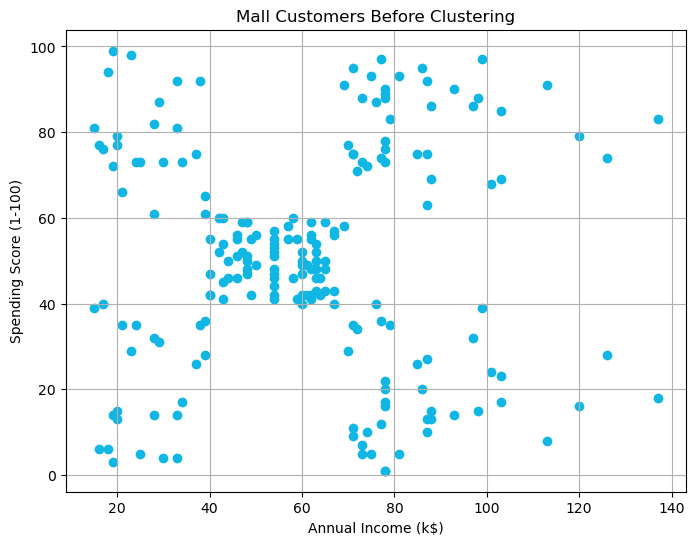

In [60]:
plt.figure(figsize=(8,6))
plt.scatter(X["Annual Income (k$)"], X["Spending Score (1-100)"], color="#10b6e4")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Mall Customers Before Clustering")
plt.savefig("plot1_raw_data.png")
plt.grid(True)
plt.show()

This plot shows the customer data before clustering. The points are scattered, and no clear groups are visible. This highlights the need for clustering techniques to identify hidden patterns.

## Data Scaling

K-Means uses distance to group data points. Therefore, the data is standardised so that all features contribute equally.

In [61]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Plot 2: Elbow Method

The elbow method helps determine the optimal number of clusters (K). It shows how inertia changes as K increases.

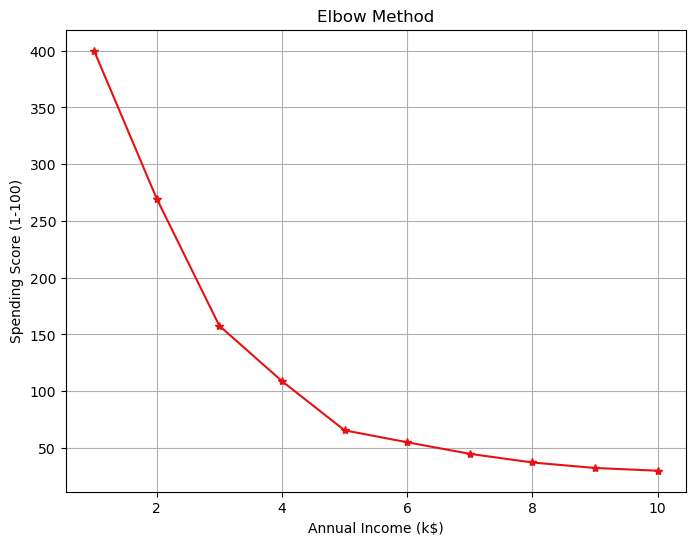

In [62]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(range(1,11), inertia, marker='*', color="#e71112")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Elbow Method")
plt.grid(True)
plt.savefig("plot2_elbow_method.png")
plt.show()

The elbow point appears around K = 5, where the decrease in inertia slows down. This suggests that 5 clusters provide a good balance between accuracy and simplicity.

## Plot 3 & 4: Effect of Different Values of K

To understand how K affects clustering, results are compared for K = 2 and K = 3.

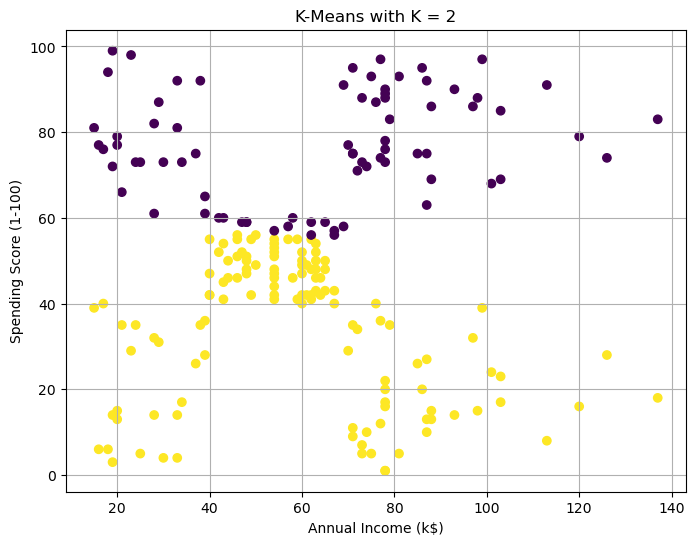

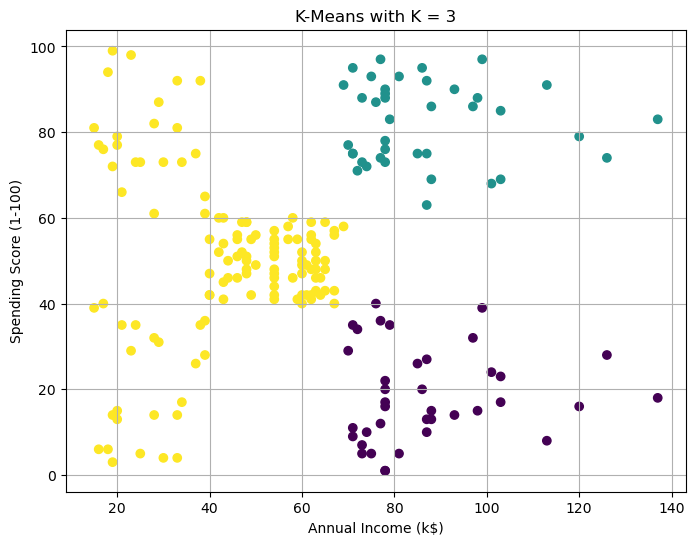

In [63]:
# K = 2
kmeans2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels2 = kmeans2.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X["Annual Income (k$)"], X["Spending Score (1-100)"], c=labels2)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means with K = 2")
plt.grid(True)
plt.savefig("plot3_k2.png")
plt.show()

# K = 3
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels3 = kmeans3.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X["Annual Income (k$)"], X["Spending Score (1-100)"], c=labels3)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means with K = 3")
plt.grid(True)
plt.savefig("plot4_k3.png")
plt.show()

## Plot 5: Final Clustering with K = 5

Based on the elbow method, K = 5 is selected. The final clusters and centroids are visualised below.

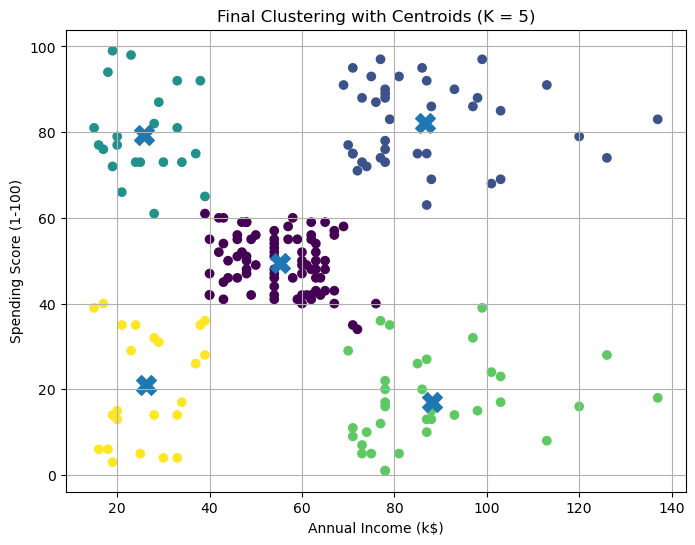

In [64]:
kmeans5 = KMeans(n_clusters=5, random_state=42, n_init=10)
labels5 = kmeans5.fit_predict(X_scaled)

centroids = scaler.inverse_transform(kmeans5.cluster_centers_)

plt.figure(figsize=(8,6))
plt.scatter(X["Annual Income (k$)"], X["Spending Score (1-100)"], c=labels5)
plt.scatter(centroids[:,0], centroids[:,1], s=200, marker='X')
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Final Clustering with Centroids (K = 5)")
plt.grid(True)
plt.savefig("plot5_final.png")
plt.show()

## Conclusion

This tutorial demonstrated how K-Means clustering can be used to group similar data points without labelled data. The results showed that the choice of K significantly affects clustering quality.

By using the elbow method and comparing different values of K, it was observed that K = 5 provides a more meaningful segmentation of customers.

K-Means is simple and effective, but it also has limitations, such as sensitivity to the choice of K and assumptions about cluster shape.